### 1. Import Library & Persiapan Super-Loop
Di kompetisi global tingkat lanjut (seperti Huawei ICT/Kaggle), loop *training* bukan sekadar `forward` dan `backward`. Anda dituntut memantau metrik secara real-time, menggunakan taktik mencegah *overfitting*, dan mencatat riwayat performa presisi tinggi.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import BertForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm.auto import tqdm  # Untuk progress bar yang interaktif di Jupyter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device aktif: {device}")

Device aktif: cuda


### 2. Parameter Global & Simulasi DataLoader
Kita atur parameter krusial seperti `eval_every` (berapa langkah sekali kita menguji model) dan `patience` (berapa kali model diizinkan tidak membaik sebelum disetop paksa / *early stopping*).

In [2]:
# --- Konfigurasi Kelas Global ---
EPOCHS = 50
BATCH_SIZE = 8
EVAL_EVERY = 10     
PATIENCE = 3        
LEARNING_RATE = 2e-5
MAX_CLIP_NORM = 1.0 

class DummyDataset(Dataset):
    def __len__(self): return 100
    def __getitem__(self, idx): 
        return {
            'input_ids': torch.randint(0, 1000, (32,)), 
            'attention_mask': torch.ones(32),
            'labels': torch.tensor(np.random.randint(0, 2), dtype=torch.long)
        }

train_loader = DataLoader(DummyDataset(), batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(DummyDataset(), batch_size=BATCH_SIZE, shuffle=False)

print(f"Total Training Steps Per Epoch: {len(train_loader)}")

Total Training Steps Per Epoch: 13


### 3. Model, Optimizer, dan Learning Rate Scheduler (Warmup)
Di kompetisi global, *Learning Rate* konstan berpotensi membuat model terjebak (*local minima*). Praktik mutlak di Transformers adalah memakai `Linear Scheduler dengan Warmup`, sehingga nilai LR memulainya dari sangat lambat lalu memuncak, lalu turun perlahan.

In [3]:
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [4]:
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

total_step = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_step)
scheduler = get_linear_schedule_with_warmup(optimizer=optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_step)

### 4. Siklus Training Super-Loop (Tqdm, Eval-Every, Grad Clipping, Early Stopping)
Ini adalah **TEMPLAT KERANGKA WAJIB** *Giant Loop* (Super Loop) yang mencakup 90% standar pembuatan file submission / penugasan model transformer di tingkat industri. Semua komponen canggih dimasukkan ke dalam blok ini.

In [5]:
train_loss_history, valid_loss_history, eval_steps = [], [], []
train_acc_history, valid_acc_history = [], []
global_step = 0
best_valid_loss = float('inf')
no_improve_counter = 0

def save_check_point(model, path="best_model.pt"):
    torch.save({'model_state_dict': model.state_dict()}, path)

for epoch in range(EPOCHS):
    model.train()
    batch_loader = tqdm(train_loader, desc=f"train epoch {epoch + 1}", leave=True)
    running_loss = 0.0
    running_corect = 0
    running_sample = 0

    for batch in batch_loader:
        global_step += 1

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        # FP
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits
        pred = logits.argmax(dim=-1)
        running_corect += torch.sum(pred == labels).item()
        running_sample += labels.size(0)
        running_loss += loss.item()
        # BP
        optimizer.zero_grad()
        outputs.loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_CLIP_NORM)

        optimizer.step()
        scheduler.step()

        batch_loader.set_postfix({'step lost' : f"{loss.item():.4f}", "acc" : f"{running_corect/running_sample:.4f}"})

        if global_step % EVAL_EVERY == 0:
            model.eval()
            valid_loss = 0.0
            valid_corect = 0
            valid_sample = 0
            with torch.no_grad():
                for v_batch in valid_loader:
                    input_ids = v_batch["input_ids"].to(device)
                    attention_mask = v_batch["attention_mask"].to(device)
                    labels = v_batch["labels"].to(device)
                    # FP
                    outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                    loss = outputs.loss
                    logits = outputs.logits
                    pred = logits.argmax(dim=-1)
                    valid_corect += torch.sum(pred == labels).item()
                    valid_sample += labels.size(0)
                    valid_loss += loss.item()
                
            avg_loss_train = running_loss / EVAL_EVERY
            avg_acc_train = running_corect / running_sample

            avg_loss_val = valid_loss / len(valid_loader)
            avg_acc_valid = valid_corect / valid_sample

            train_loss_history.append(avg_loss_train)
            valid_loss_history.append(avg_loss_val)
            eval_steps.append(global_step)
            train_acc_history.append(avg_acc_train)
            valid_acc_history.append(avg_acc_valid)

            if avg_loss_train < best_valid_loss:
                best_valid_loss = avg_loss_train
                save_check_point(model)
                no_improve_counter = 0
            else:
                no_improve_counter += 1
            
            if no_improve_counter > PATIENCE:
                break

            running_loss = 0.0
            running_corect = 0
            running_sample = 0

            model.train()

    if no_improve_counter > PATIENCE:
        print(f"Model save because early stop at epoch {epoch + 1}")
        break

print("Training Done")


train epoch 1:   0%|          | 0/13 [00:00<?, ?it/s]

train epoch 2:   0%|          | 0/13 [00:00<?, ?it/s]

train epoch 3:   0%|          | 0/13 [00:00<?, ?it/s]

train epoch 4:   0%|          | 0/13 [00:00<?, ?it/s]

train epoch 5:   0%|          | 0/13 [00:00<?, ?it/s]

train epoch 6:   0%|          | 0/13 [00:00<?, ?it/s]

train epoch 7:   0%|          | 0/13 [00:00<?, ?it/s]

Model save because early stop at epoch 7
Training Done


### 5. Visualisasi Metrik (Plotting Loss Curve)
Setelah loop besar di atas selesai menyimpan variabel ke `.append()`, tugas Anda adalah menggambarkannya menggunakan kurva *Matplotlib* guna memantau konvergensi model (Mendeteksi Overfitting).

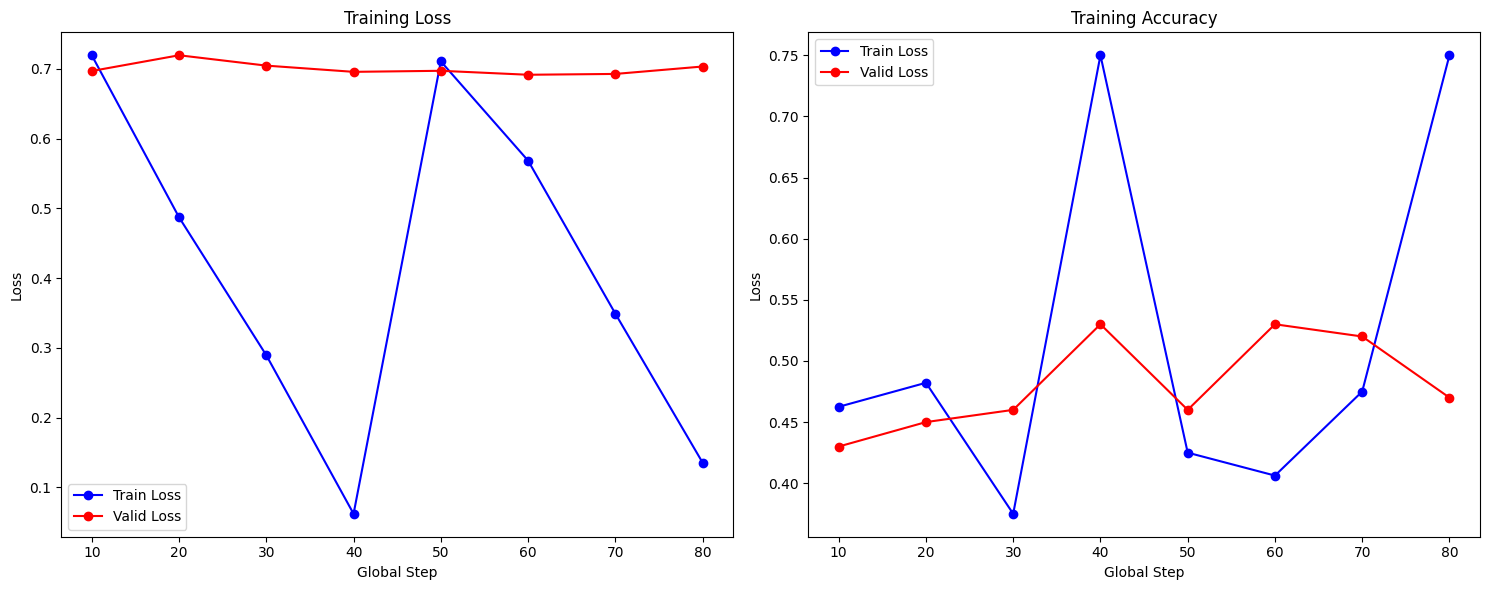

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(eval_steps, train_loss_history, label="Train Loss", color="blue", marker='o')
axes[0].plot(eval_steps, valid_loss_history, label="Valid Loss", color="red", marker='o')
axes[0].set_xlabel('Global Step')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_title('Training Loss')

axes[1].plot(eval_steps, train_acc_history, label="Train Loss", color="blue", marker='o')
axes[1].plot(eval_steps, valid_acc_history, label="Valid Loss", color="red", marker='o')
axes[1].set_xlabel('Global Step')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].set_title('Training Accuracy')

plt.tight_layout()
plt.show()

### 6. Evaluasi Skala Penuh Akhir (Confusion Matrix & Classification Report)
Loop validasi standar hanya mengukur *Loss*. Untuk *competitions score*, kita membidik evaluasi tingkat tinggi `F1-Score`, `Precision`, dan Matrix penyebaran tebakan memakai `sklearn` & `seaborn`.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


accuracy : 0.49
report :               precision    recall  f1-score   support

           0       0.00      0.00      0.00        51
           1       0.49      1.00      0.66        49

    accuracy                           0.49       100
   macro avg       0.24      0.50      0.33       100
weighted avg       0.24      0.49      0.32       100



c:\Users\Dindin\.pyenv\pyenv-win\versions\3.10.11\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dindin\.pyenv\pyenv-win\versions\3.10.11\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dindin\.pyenv\pyenv-win\versions\3.10.11\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

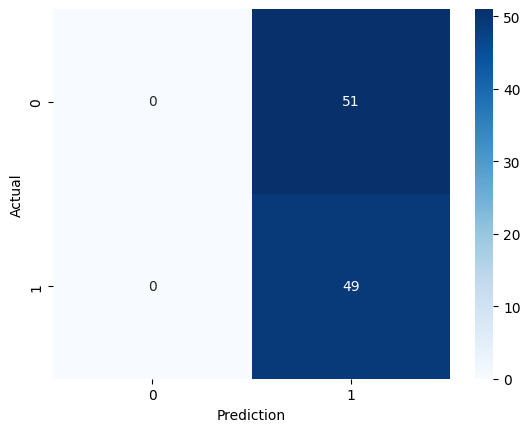

In [10]:
def evaluate_final(model, dataloader):
    all_true = []
    all_pred = []

    model.eval()

    with torch.no_grad():
        for data in dataloader:
            input_ids = data['input_ids'].to(device)
            attention_mask = data['attention_mask'].to(device)
            labels = data['labels'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            logits = outputs.logits
            pred = torch.argmax(logits, dim=1).cpu()
            all_true.extend(labels.cpu())
            all_pred.extend(pred)
            
    print(f"accuracy : {accuracy_score(all_true, all_pred)}")
    print(f"report : {classification_report(all_true, all_pred)}")

    cm = confusion_matrix(all_true, all_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Actual')
    plt.show()

model_state_dict = torch.load('model_bert.pt')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased').to(device)
model.load_state_dict(model_state_dict['model_state_dict'])
evaluate_final(model, valid_loader)